In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

In [ ]:
#Data Frame
brfss = pd.read_csv("LLCP2023.csv")
brfss['Index'] = brfss.index
brfss.head()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_RFBING6,_DRNKWK2,_RFDRHV8,_FLSHOT7,_PNEUMO3,_AIDTST4,_RFSEAT2,_RFSEAT3,_DRNKDRV,Index
0,1.0,1.0,b'03012023',b'03',b'01',b'2023',1100.0,b'2023000001',2.023000e+09,1.0,...,1.0,5.397605e-79,1.0,2.0,2.0,2.0,1.0,1.0,9.0,0
1,1.0,1.0,b'01062023',b'01',b'06',b'2023',1100.0,b'2023000002',2.023000e+09,1.0,...,1.0,5.397605e-79,1.0,1.0,1.0,2.0,1.0,1.0,9.0,1
2,1.0,1.0,b'03082023',b'03',b'08',b'2023',1100.0,b'2023000003',2.023000e+09,1.0,...,1.0,5.397605e-79,1.0,1.0,1.0,2.0,1.0,1.0,9.0,2
3,1.0,1.0,b'03062023',b'03',b'06',b'2023',1100.0,b'2023000004',2.023000e+09,1.0,...,1.0,5.397605e-79,1.0,1.0,1.0,1.0,1.0,1.0,9.0,3
4,1.0,1.0,b'01062023',b'01',b'06',b'2023',1100.0,b'2023000005',2.023000e+09,1.0,...,1.0,4.700000e+01,1.0,2.0,1.0,2.0,1.0,1.0,2.0,4


In [ ]:
#New Data Frame with Variables that we will use
data = brfss[['Index','EXEROFT1','MENTHLTH']]
#Data Exploration
misscnt = data.isnull().sum(axis=1)
print(misscnt.value_counts())

0    4682
1    1948
Name: count, dtype: int64


In [ ]:
#Drop Nulls of Two Main Variables
new_data = data.dropna(subset=['EXEROFT1', 'MENTHLTH'])
misscnt2 = new_data.isnull().sum(axis=1)
print(misscnt2.value_counts())

0    4682
Name: count, dtype: int64


In [ ]:
#Data Cleaning of EXEROFT1 Variable
#Convert 101-199 to 1-99
new_data.loc[
    (new_data['EXEROFT1'] > 100) & (new_data['EXEROFT1'] < 200),
    'EXEROFT1'
] = new_data['EXEROFT1'] - 100
#Convert 201-299 to (1-99)/4
new_data.loc[
    (new_data['EXEROFT1'] > 200) & (new_data['EXEROFT1'] < 300),
    'EXEROFT1'
] = ((new_data['EXEROFT1'] - 200)/4).round()
#Drop rows with values greater than 100
new_data = new_data[new_data['EXEROFT1'] <= 100]
new_data.describe()

,Index,EXEROFT1,MENTHLTH
count,4578.000000,4578.00000,4578.000000
mean,3401.892529,4.40083,59.311490
std,1887.068789,4.74026,38.120309
min,1.000000,0.00000,1.000000
25%,1797.250000,2.00000,10.000000
50%,3419.500000,4.00000,88.000000
75%,5036.500000,6.00000,88.000000
max,6629.000000,99.00000,99.000000


In [ ]:
#Data Cleaning of MENTHLTH Variable
new_data.loc[
    (new_data['MENTHLTH'] == 88),
    'MENTHLTH'
] = 0
new_data = new_data[new_data['MENTHLTH'] <= 30]
new_data.describe()

,Index,EXEROFT1,MENTHLTH
count,4523.000000,4523.000000,4523.000000
mean,3397.208269,4.395976,3.612425
std,1885.279914,4.735643,7.549389
min,1.000000,0.000000,0.000000
25%,1796.000000,2.000000,0.000000
50%,3415.000000,4.000000,0.000000
75%,5027.500000,6.000000,3.000000
max,6629.000000,99.000000,30.000000


In [ ]:
#Removal of Outliers in EXEROFT1 Variable
#We decided to remove any observation where the person surveyed said they worked
#out more than 28 times per week because we decided this was implausible.
new_data = new_data[new_data['EXEROFT1'] <= 28]
new_data.describe()

,Index,EXEROFT1,MENTHLTH
count,4506.000000,4506.000000,4506.000000
mean,3392.889037,4.198624,3.606303
std,1884.042409,2.884273,7.543637
min,1.000000,0.000000,0.000000
25%,1792.500000,2.000000,0.000000
50%,3406.000000,4.000000,0.000000
75%,5017.500000,6.000000,3.000000
max,6629.000000,28.000000,30.000000


In [ ]:
#Simple Linear Regression Plot
def getlm(df):
  Y = df['MENTHLTH']
  X = df['EXEROFT1']
  X = sm.add_constant(X)
  return sm.OLS(Y, X).fit()
getlm(new_data).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               MENTHLTH   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.288
Date:                Thu, 27 Nov 2025   Prob (F-statistic):              0.256
Time:                        03:24:54   Log-Likelihood:                -15498.
No. Observations:                4506   AIC:                         3.100e+04
Df Residuals:                    4504   BIC:                         3.101e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.7920      0.198     19.105      0.000       3.403       4.181
EXEROFT1      -0.0442      0.039     -1.135      0.256      -0.121       0.032
==============================================================================
Omnibus:                     2251.804   Durbin-Watson:                   1.922
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10389.885
Skew:                           2.521   Prob(JB):                         0.00
Kurtosis:                       8.470   Cond. No.                         9.24
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
#Power Transformation of X and y
pt = PowerTransformer(method='box-cox')

x = new_data[['EXEROFT1']]+1
new_data['bc'] = pt.fit_transform(x)
pt.lambdas_

array([0.18968277])

In [ ]:
#New Regression Model
def getlm_new(df):
  Y = df['MENTHLTH']
  X = np.log(df['EXEROFT1']+1)
  X = sm.add_constant(X)
  return sm.OLS(Y, X).fit()
getlm_new(new_data).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               MENTHLTH   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.401
Date:                Thu, 27 Nov 2025   Prob (F-statistic):             0.0652
Time:                        03:24:54   Log-Likelihood:                -15497.
No. Observations:                4506   AIC:                         3.100e+04
Df Residuals:                    4504   BIC:                         3.101e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1951      0.338     12.396      0.000       3.532       4.859
EXEROFT1      -0.3891      0.211     -1.844      0.065      -0.803       0.025
==============================================================================
Omnibus:                     2251.895   Durbin-Watson:                   1.922
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10395.230
Skew:                           2.521   Prob(JB):                         0.00
Kurtosis:                       8.473   Cond. No.                         6.56
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: ylabel='EXEROFT1'>

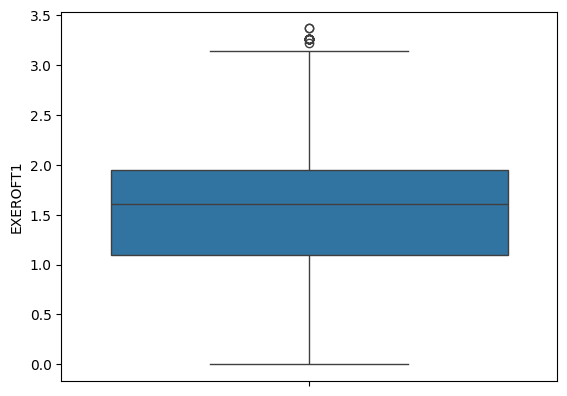

In [ ]:
#Boxplot of log(x)
sns.boxplot(y=np.log(new_data['EXEROFT1']+1))

<Axes: ylabel='MENTHLTH'>

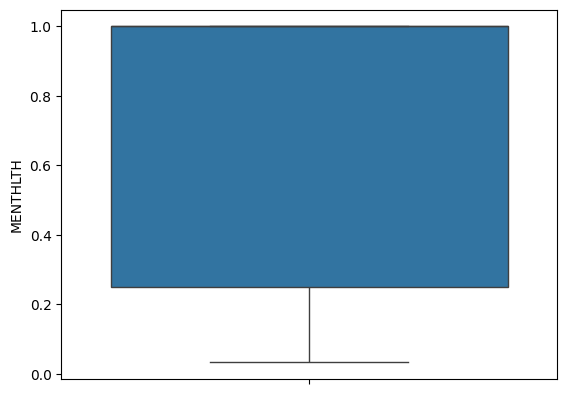

In [ ]:
#Boxplot of y
sns.boxplot(y=1/(new_data['MENTHLTH']+1))

In [ ]:
#Cleaning of Possible Control Variables
control_variables = ['Index','AVEDRNK3','CHILDREN', 'EMPLOY1']
controls = brfss[control_variables]
controls.head()

,Index,AVEDRNK3,CHILDREN,EMPLOY1
0,0,NaN,88.0,7.0
1,1,NaN,88.0,7.0
2,2,NaN,88.0,7.0
3,3,NaN,88.0,7.0
4,4,1.0,88.0,8.0


In [ ]:
#Drop Nulls of Controls
new_controls = controls.dropna(subset=['AVEDRNK3', 'CHILDREN', 'EMPLOY1'])

In [ ]:
#Cleaning of AVEDRNK3 Variable
new_controls.loc[
    (new_controls['AVEDRNK3'] == 88),
    'AVEDRNK3'
] = 0
new_controls = new_controls[new_controls['AVEDRNK3'] <= 76]
new_controls.describe()

,Index,AVEDRNK3,CHILDREN,EMPLOY1
count,2785.000000,2785.000000,2785.000000,2785.000000
mean,3583.761939,2.146140,65.956553,3.630521
std,1837.764456,1.818006,37.667842,2.856783
min,4.000000,0.000000,1.000000,1.000000
25%,2012.000000,1.000000,4.000000,1.000000
50%,3661.000000,2.000000,88.000000,2.000000
75%,5189.000000,2.000000,88.000000,7.000000
max,6629.000000,20.000000,99.000000,9.000000


In [ ]:
#Cleaning of CHILDREN Variable
new_controls.loc[
    (new_controls['CHILDREN'] == 88),
    'CHILDREN'
] = 0
new_controls = new_controls[new_controls['CHILDREN'] <= 87]
new_controls.describe()

,Index,AVEDRNK3,CHILDREN,EMPLOY1
count,2773.000000,2773.000000,2773.000000,2773.000000
mean,3579.309773,2.143887,0.472052,3.637216
std,1837.074089,1.811618,0.947977,2.858182
min,4.000000,0.000000,0.000000,1.000000
25%,2009.000000,1.000000,0.000000,1.000000
50%,3652.000000,2.000000,0.000000,2.000000
75%,5184.000000,2.000000,1.000000,7.000000
max,6629.000000,20.000000,10.000000,9.000000


In [ ]:
#Cleaning of EMPLOY1 Variable
new_controls = new_controls[new_controls['EMPLOY1'] <= 8]
new_controls["Unemployed"] = 1
new_controls.loc[new_controls['EMPLOY1'].isin([1,2,5,6,7]), 'Unemployed'] = 0
new_controls.describe()

,Index,AVEDRNK3,CHILDREN,EMPLOY1,Unemployed
count,2761.000000,2761.00000,2761.000000,2761.000000,2761.000000
mean,3578.243752,2.13908,0.472293,3.613908,0.075697
std,1836.925951,1.79498,0.949090,2.842383,0.264561
min,4.000000,0.00000,0.000000,1.000000,0.000000
25%,2008.000000,1.00000,0.000000,1.000000,0.000000
50%,3652.000000,2.00000,0.000000,2.000000,0.000000
75%,5185.000000,2.00000,1.000000,7.000000,0.000000
max,6629.000000,20.00000,10.000000,8.000000,1.000000


In [ ]:
#Removal of Outliers
new_controls = new_controls[new_controls['AVEDRNK3'] <= 25]
new_controls = new_controls[new_controls['CHILDREN'] <= 20]
new_controls.describe()

,Index,AVEDRNK3,CHILDREN,EMPLOY1,Unemployed
count,2761.000000,2761.00000,2761.000000,2761.000000,2761.000000
mean,3578.243752,2.13908,0.472293,3.613908,0.075697
std,1836.925951,1.79498,0.949090,2.842383,0.264561
min,4.000000,0.00000,0.000000,1.000000,0.000000
25%,2008.000000,1.00000,0.000000,1.000000,0.000000
50%,3652.000000,2.00000,0.000000,2.000000,0.000000
75%,5185.000000,2.00000,1.000000,7.000000,0.000000
max,6629.000000,20.00000,10.000000,8.000000,1.000000


In [ ]:
#Joining of new_data table and new_controls table
joined_table = pd.merge(new_data, new_controls, on='Index')
joined_table.describe()

,Index,EXEROFT1,MENTHLTH,bc,AVEDRNK3,CHILDREN,EMPLOY1,Unemployed
count,2166.000000,2166.000000,2166.000000,2166.000000,2166.000000,2166.000000,2166.000000,2166.000000
mean,3596.902124,4.057710,3.591874,-0.044229,2.074792,0.467221,3.518467,0.055863
std,1827.677536,2.849722,7.141565,0.967710,1.684035,0.946410,2.807180,0.229711
min,4.000000,0.000000,0.000000,-2.543903,0.000000,0.000000,1.000000,0.000000
25%,2020.750000,2.000000,0.000000,-0.806441,1.000000,0.000000,1.000000,0.000000
50%,3682.500000,4.000000,0.000000,0.133323,2.000000,0.000000,2.000000,0.000000
75%,5183.250000,5.000000,3.000000,0.491409,2.000000,1.000000,7.000000,0.000000
max,6629.000000,28.000000,30.000000,4.160636,20.000000,10.000000,8.000000,1.000000


In [ ]:
#New Multiple Regression with controls included
def getlm(df):
  Y = 1/(df['MENTHLTH']+1)
  X = np.log(df[['EXEROFT1','AVEDRNK3','CHILDREN','EMPLOY1','Unemployed']]+1)
  X = sm.add_constant(X)
  return sm.OLS(Y, X).fit()
getlm(joined_table).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               MENTHLTH   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     32.42
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           5.71e-32
Time:                        03:32:30   Log-Likelihood:                -1030.5
No. Observations:                2166   AIC:                             2073.
Df Residuals:                    2160   BIC:                             2107.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6093      0.041     14.974      0.000       0.530       0.689
EXEROFT1       0.0380      0.016      2.323      0.020       0.006       0.070
AVEDRNK3      -0.0765      0.021     -3.568      0.000      -0.119      -0.034
CHILDREN      -0.0886      0.019     -4.638      0.000      -0.126      -0.051
EMPLOY1        0.0952      0.014      6.713      0.000       0.067       0.123
Unemployed    -0.3755      0.054     -6.901      0.000      -0.482      -0.269
==============================================================================
Omnibus:                    21022.128   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              247.411
Skew:                          -0.431   Prob(JB):                     1.88e-54
Kurtosis:                       1.586   Cond. No.                         16.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
#Instrumental Variable Model
#Cleaning of Exogenous Instrument
exo = brfss[['Index','HEIGHT3']]
exo = exo.dropna(subset=['HEIGHT3'])

In [ ]:
exo = exo[exo['HEIGHT3']<=711]
exo.loc[:, "height_in"] = (exo["HEIGHT3"] // 100) * 12 + (exo["HEIGHT3"] % 100)
exo.describe()

,Index,HEIGHT3,height_in
count,6414.000000,6414.000000,6414.000000
mean,3307.302307,520.099938,67.052229
std,1910.691849,38.138215,4.131804
min,0.000000,300.000000,36.000000
25%,1658.250000,504.000000,64.000000
50%,3299.500000,507.000000,67.000000
75%,4960.750000,510.000000,70.000000
max,6629.000000,702.000000,86.000000


In [ ]:
#Removal of Outliers
exo = exo[exo['height_in'] <= 86]
exo = exo[exo['height_in'] >= 53]
exo.describe()

,Index,HEIGHT3,height_in
count,6411.000000,6411.000000,6411.000000
mean,3307.604586,520.170800,67.062081
std,1910.469933,37.991616,4.104700
min,0.000000,407.000000,55.000000
25%,1658.500000,504.000000,64.000000
50%,3300.000000,507.000000,67.000000
75%,4960.500000,510.000000,70.000000
max,6629.000000,702.000000,86.000000


In [ ]:
iv_merge = pd.merge(new_data, exo, on='Index')
iv_merge.describe()

,Index,EXEROFT1,MENTHLTH,bc,HEIGHT3,height_in
count,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000
mean,3385.456313,4.202196,3.624886,0.000641,522.603385,67.366423
std,1882.343459,2.897757,7.542222,1.001309,38.525833,4.107484
min,1.000000,0.000000,0.000000,-2.543903,408.000000,56.000000
25%,1789.750000,2.000000,0.000000,-0.806441,504.000000,64.000000
50%,3393.500000,4.000000,0.000000,0.133323,507.000000,67.000000
75%,5004.500000,6.000000,3.000000,0.803978,510.000000,70.000000
max,6629.000000,28.000000,30.000000,4.160636,702.000000,86.000000


In [ ]:
!pip install linearmodels
from linearmodels.iv import IV2SLS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.5 MB/s eta 0:00:00


In [ ]:
iv_merge.loc[:, "log_exer"] = np.log(iv_merge["EXEROFT1"])
iv_merge.head()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Index,EXEROFT1,MENTHLTH,bc,HEIGHT3,height_in,log_exer
0,1,6.0,0.0,0.803978,409.0,57.0,1.791759
1,2,1.0,2.0,-1.490189,504.0,64.0,0.000000
2,3,3.0,0.0,-0.288415,506.0,66.0,1.098612
3,4,2.0,0.0,-0.806441,508.0,68.0,0.693147
4,5,3.0,3.0,-0.288415,502.0,62.0,1.098612


In [ ]:
iv_merge['MENTHLTH_inv'] = 1 / (iv_merge['MENTHLTH']+1)
iv_merge['EXEROFT1_log'] = np.log(iv_merge['EXEROFT1']+1)

In [ ]:
iv_model = IV2SLS.from_formula(
    "MENTHLTH_inv ~ 1 + [EXEROFT1_log ~ height_in]",
    data=iv_merge
).fit()

print(iv_model.summary)


                          IV-2SLS Estimation Summary                          
Dep. Variable:           MENTHLTH_inv   R-squared:                     -22.504
Estimator:                    IV-2SLS   Adj. R-squared:                -22.510
No. Observations:                4372   F-statistic:                    0.7871
Date:                Thu, Nov 27 2025   P-value (F-stat)                0.3750
Time:                        03:39:24   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
Intercept        6.0299     6.0099     1.0033     0.3157     -5.7492      17.809
EXEROFT1_log    -3.5223     3.9702    -0.887

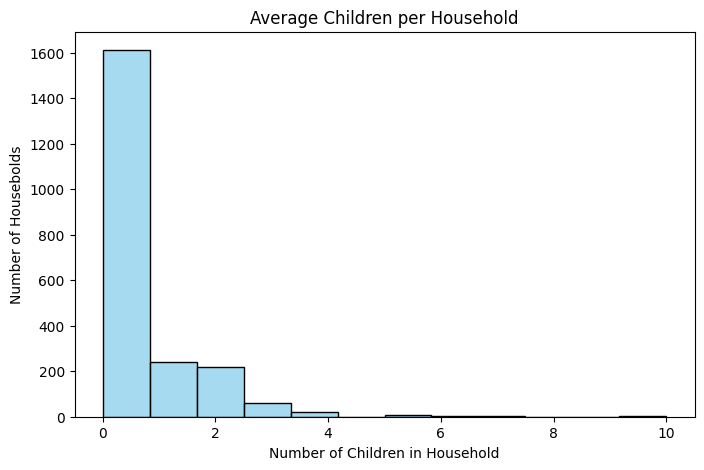

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(joined_table['CHILDREN'],bins= 12, color='skyblue')

plt.xlabel("Number of Children in Household")
plt.ylabel("Number of Housebolds")
plt.title("Average Children per Household")

plt.show()

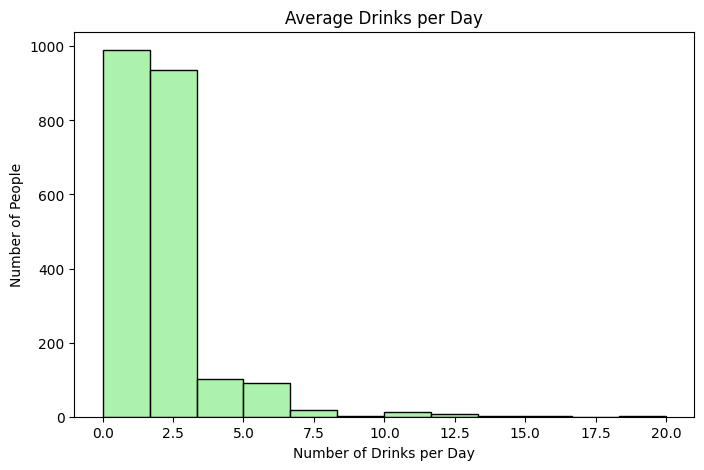

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(joined_table['AVEDRNK3'],bins= 12, color='lightgreen')

plt.xlabel("Number of Drinks per Day")
plt.ylabel("Number of People")
plt.title("Average Drinks per Day")

plt.show()

In [ ]:
mapping = {
    1: "Employed for wages",
    2: "Self-employed",
    3: "Out of work for 1+ year",
    4: "Out of work for less than a year",
    5: "Not looking for work",
    6: "Student",
    7: "Retired",
    8: "Unable to work"
}

joined_table["Employment_Label"] = joined_table["EMPLOY1"].map(mapping)


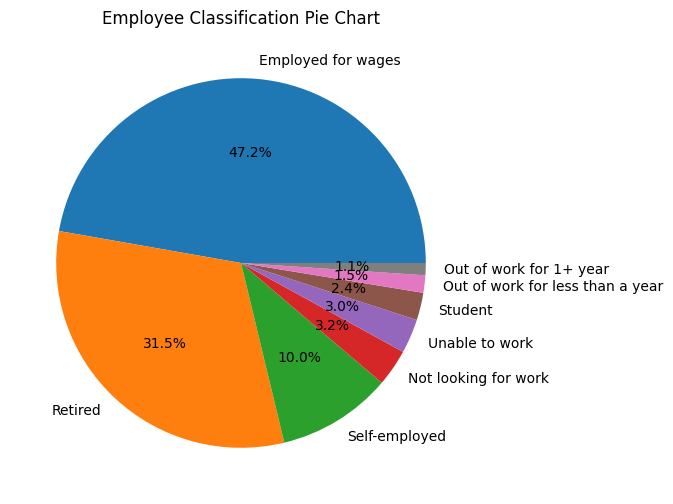

In [ ]:
counts = joined_table["Employment_Label"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("Employee Classification Pie Chart")
plt.show()

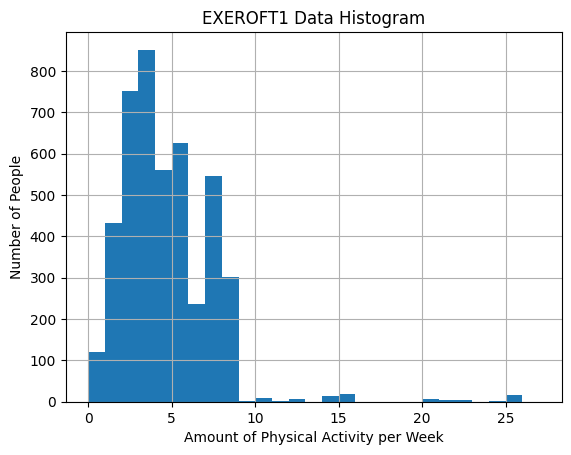

In [ ]:
new_data['EXEROFT1'].hist(bins=np.arange(0, 28, 1))

plt.xlabel("Amount of Physical Activity per Week")
plt.ylabel("Number of People")
plt.title("EXEROFT1 Data Histogram")

plt.show()

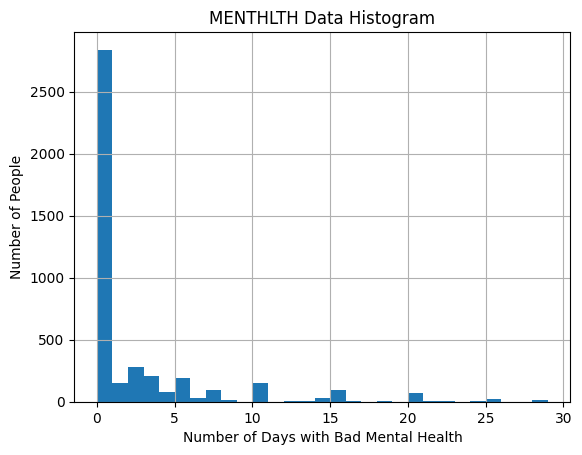

In [ ]:
new_data['MENTHLTH'].hist(bins=np.arange(0, 30, 1))

plt.xlabel("Number of Days with Bad Mental Health")
plt.ylabel("Number of People")
plt.title("MENTHLTH Data Histogram")

plt.show()

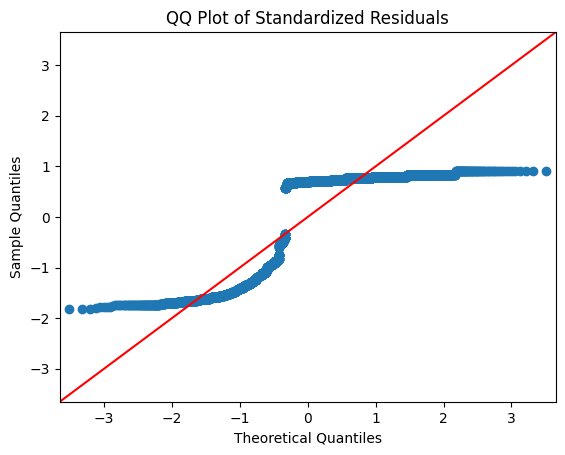

In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Example data
np.random.seed(0)
X = np.log(new_data['EXEROFT1']+1)
y = 1/(1+new_data['MENTHLTH'])
# Add constant for intercept
X = sm.add_constant(X)

# Fit OLS
model = sm.OLS(y, X).fit()

# Get standardized residuals
standardized_residuals = model.get_influence().resid_studentized_internal

# QQ plot
sm.qqplot(standardized_residuals, line='45')
plt.title("QQ Plot of Standardized Residuals")
plt.show()

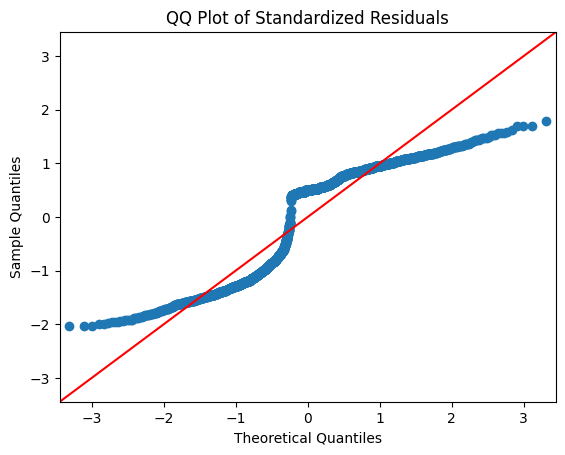

In [ ]:
#New Multiple Regression with controls included
def getlm(df):
  Y = 1/(df['MENTHLTH']+1)
  X = np.log(df[['EXEROFT1','AVEDRNK3','CHILDREN','EMPLOY1','Unemployed']]+1)
  X = sm.add_constant(X)
  return sm.OLS(Y, X).fit()
model1 = getlm(joined_table)
# Get standardized residuals
standardized_residuals = model1.get_influence().resid_studentized_internal

# QQ plot
sm.qqplot(standardized_residuals, line='45')
plt.title("QQ Plot of Standardized Residuals")
plt.show()